In [1]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

#Load data
conn = sqlite3.connect("churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)
print("Data loaded:", df.shape)

Data loaded: (7043, 21)


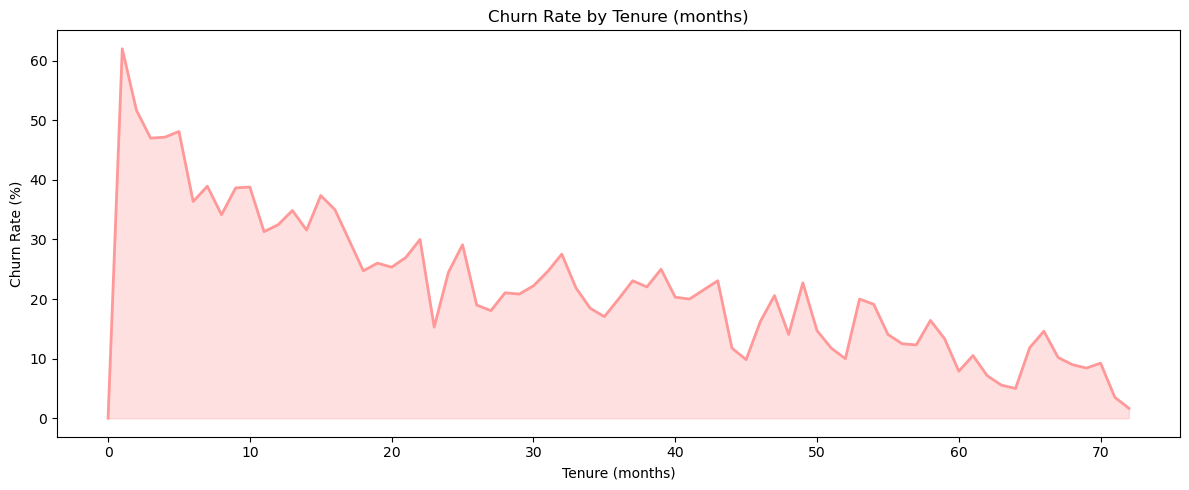

In [2]:
#Monthly churn trend
churn_trend = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
churn_trend.columns = ['tenure', 'churn_rate']

plt.figure(figsize=(12, 5))
plt.plot(churn_trend['tenure'], churn_trend['churn_rate'], 
         color='#ff9999', linewidth=2)
plt.fill_between(churn_trend['tenure'], churn_trend['churn_rate'], 
                 alpha=0.3, color='#ff9999')
plt.title('Churn Rate by Tenure (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_20040\1718743909.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_type = df.groupby('customer_type')['Churn'].apply(
C:\Users\nandi\AppData\Local\Temp\ipykernel_20040\1718743909.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_type, x='customer_type', y='churn_rate',


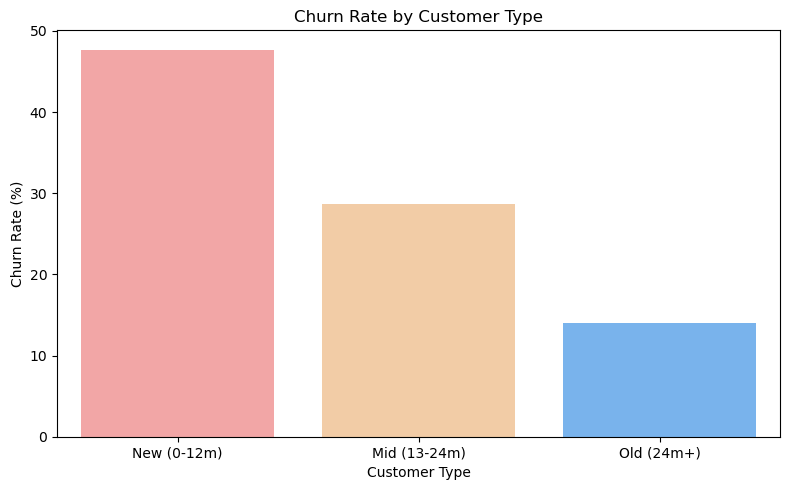

In [3]:
#New vs Old customers
df['customer_type'] = pd.cut(df['tenure'], 
                              bins=[0, 12, 24, 72], 
                              labels=['New (0-12m)', 'Mid (13-24m)', 'Old (24m+)'])

plt.figure(figsize=(8, 5))
churn_by_type = df.groupby('customer_type')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
churn_by_type.columns = ['customer_type', 'churn_rate']

sns.barplot(data=churn_by_type, x='customer_type', y='churn_rate',
            palette=['#ff9999','#ffcc99','#66b3ff'])
plt.title('Churn Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_20040\2320281439.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='churn_rate',
C:\Users\nandi\AppData\Local\Temp\ipykernel_20040\2320281439.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='churn_rate',
C:\Users\nandi\AppData\Local\Temp\ipykernel_20040\2320281439.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=security_churn, x='OnlineSecurity', y='churn_rate',
C:\Users\nandi\AppData\Local\Temp\ipyker

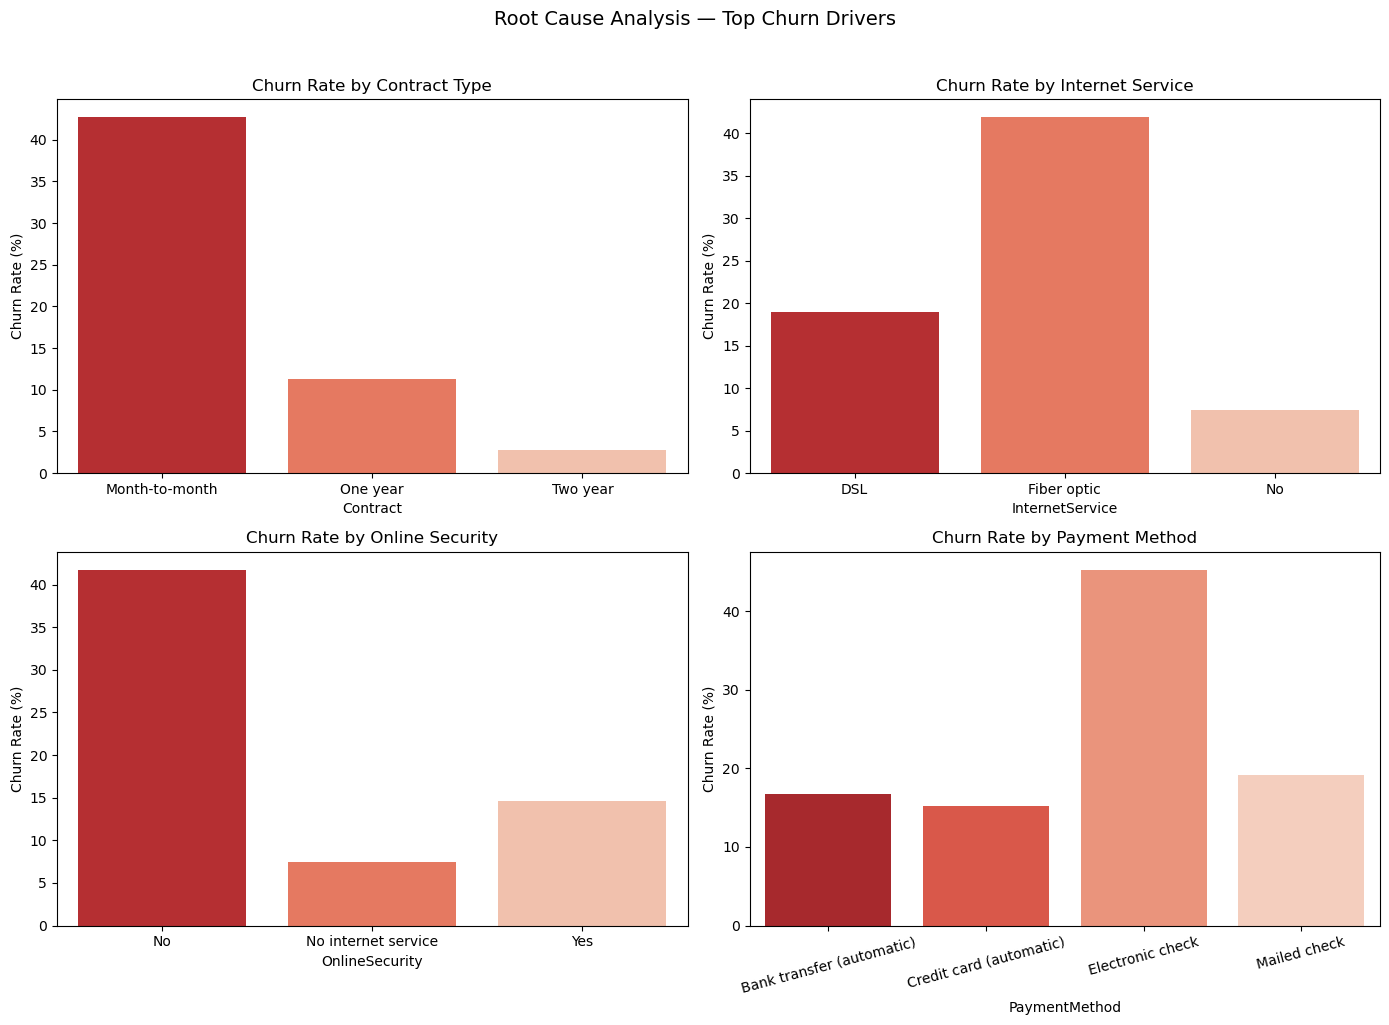

In [4]:
#Root cause: Top churn drivers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#1. Contract type churn rate
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
contract_churn.columns = ['Contract', 'churn_rate']
sns.barplot(data=contract_churn, x='Contract', y='churn_rate',
            palette='Reds_r', ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')

#2. Internet service churn rate
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
internet_churn.columns = ['InternetService', 'churn_rate']
sns.barplot(data=internet_churn, x='InternetService', y='churn_rate',
            palette='Reds_r', ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')

#3. Online security churn rate
security_churn = df.groupby('OnlineSecurity')['Churn'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
security_churn.columns = ['OnlineSecurity', 'churn_rate']
sns.barplot(data=security_churn, x='OnlineSecurity', y='churn_rate',
            palette='Reds_r', ax=axes[1,0])
axes[1,0].set_title('Churn Rate by Online Security')
axes[1,0].set_ylabel('Churn Rate (%)')

#4. Payment method churn rate
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
payment_churn.columns = ['PaymentMethod', 'churn_rate']
sns.barplot(data=payment_churn, x='PaymentMethod', y='churn_rate',
            palette='Reds_r', ax=axes[1,1])
axes[1,1].set_title('Churn Rate by Payment Method')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Root Cause Analysis — Top Churn Drivers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
#Summary stats - churned vs non churned customers
summary = df.groupby('Churn').agg(
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean'),
    total_customers=('customerID', 'count')
).round(2)

print("=== Churned vs Non-Churned Customer Profile ===")
print(summary)

=== Churned vs Non-Churned Customer Profile ===
       avg_tenure  avg_monthly_charges  avg_total_charges  total_customers
Churn                                                                     
No          37.57                61.27            2555.34             5174
Yes         17.98                74.44            1531.80             1869
